# ME-XBAL (Multilingual Emotion eXplainable BALancer)

In [1]:
# ==========================================
# 🔬 TOKOPEDIA EMOTION DATASET (SINGLE LABEL)
# ==========================================
import pandas as pd
import numpy as np
import torch
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ==========================================
# 1. LOAD DATASET
# ==========================================
df = pd.read_csv('/kaggle/input/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv')

print("Columns:", df.columns)
print(df.head())

# Sesuaikan nama kolom
text_col = "Customer Review"
label_col = "Emotion"

# Drop missing
df = df[[text_col, label_col]].dropna()

# ==========================================
# 2. LABEL ENCODING
# ==========================================
le = LabelEncoder()
df['label'] = le.fit_transform(df[label_col])

print("\nClasses:", le.classes_)

# ==========================================
# 3. TRAIN TEST SPLIT
# ==========================================
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

y_train = df_train['label'].values
y_test  = df_test['label'].values

# ==========================================
# 4. LOAD XLM-R
# ==========================================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# ==========================================
# 5. EMBEDDING FUNCTION
# ==========================================
def extract_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls)

    return np.vstack(embeddings)

# ==========================================
# 6. FEATURE EXTRACTION
# ==========================================
print("\n🔄 Extracting embeddings...")
X_train = extract_embeddings(df_train[text_col].astype(str).tolist())
X_test  = extract_embeddings(df_test[text_col].astype(str).tolist())

# ==========================================
# 7. PREPROCESSING
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("\nReduced dim:", X_train_pca.shape[1])

# ==========================================
# 8. TRAIN MODELS
# ==========================================
num_classes = len(le.classes_)

# XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train_pca, y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train_pca, y_train)

# ==========================================
# 9. PREDICTION (HYBRID)
# ==========================================
xgb_proba = xgb_model.predict_proba(X_test_pca)
lr_proba  = lr_model.predict_proba(X_test_pca)

hybrid_proba = 0.7 * xgb_proba + 0.3 * lr_proba
y_pred = np.argmax(hybrid_proba, axis=1)

# ==========================================
# 10. EVALUATION
# ==========================================
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
acc = accuracy_score(y_test, y_pred)

print("\n📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)")
print("="*60)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Micro F1 : {micro_f1:.4f}")
print(f"Accuracy : {acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(le.classes_)),
    target_names=le.classes_,
    zero_division=0
))

Columns: Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')
                Category                                       Product Name  \
0  Computers and Laptops  Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...   
1  Computers and Laptops  PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...   
2  Computers and Laptops                SSD Midasforce 128 Gb - Tanpa Caddy   
3  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   
4  Computers and Laptops  ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...   

                 Location   Price  Overall Rating  Number Sold  Total Review  \
0           Jakarta Utara   53500             4.9         5449          2369   
1  Kota Tangerang Selatan   72000             4.9         2359          1044   
2           Jakarta Barat  213000             5.0        12300          

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔄 Extracting embeddings...


100%|██████████| 34/34 [00:04<00:00,  7.58it/s]



Reduced dim: 116

📊 RESULTS (TOKOPEDIA DATASET - SINGLE LABEL)
Macro F1 : 0.5459
Micro F1 : 0.5954
Accuracy : 0.5954

📋 Classification Report:
              precision    recall  f1-score   support

       Anger       0.46      0.35      0.40       140
        Fear       0.44      0.36      0.39       184
       Happy       0.73      0.82      0.77       354
        Love       0.68      0.55      0.61       162
     Sadness       0.51      0.62      0.56       240

    accuracy                           0.60      1080
   macro avg       0.56      0.54      0.55      1080
weighted avg       0.59      0.60      0.59      1080



# Ablation Study

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

🔄 Extracting embeddings...


100%|██████████| 34/34 [00:05<00:00,  6.75it/s]



📊 RESULTS (TOKOPEDIA - ABLATION)
ME-XBAL             : 0.5594
XLM-R LR            : 0.5527
XLM-R XGB           : 0.5159
XLM-R Hybrid        : 0.5594
IndoBERT LR         : 0.5312
IndoBERT XGB        : 0.5114
IndoBERT Hybrid     : 0.5570


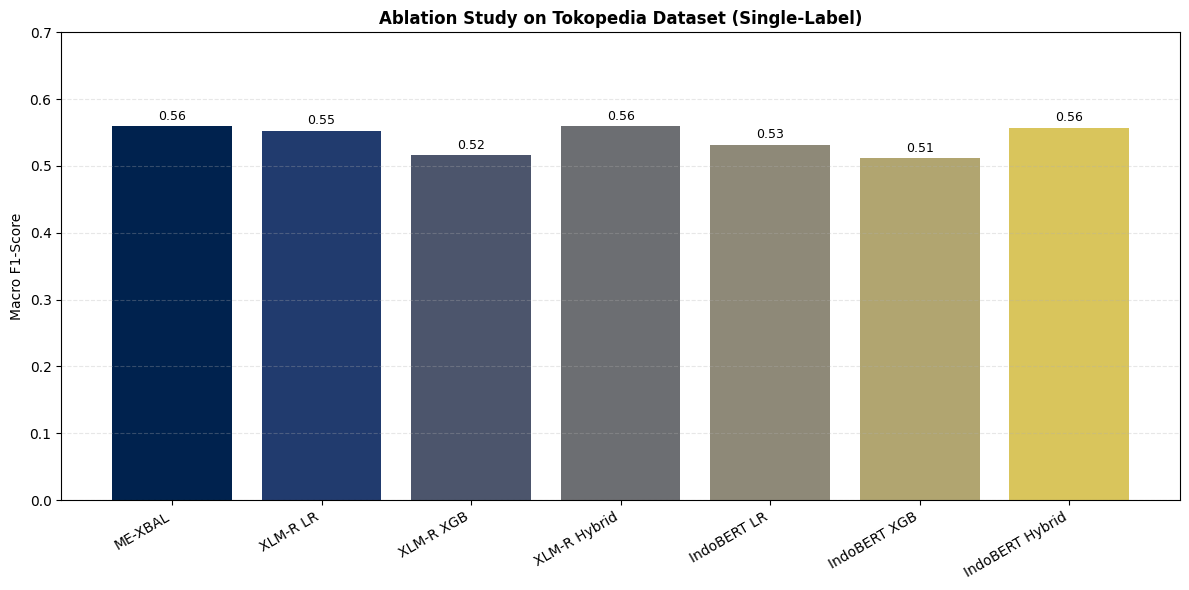

In [2]:
# ==========================================
# 🔬 ABLATION STUDY - TOKOPEDIA DATASET
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# ================================
# LOAD TRANSFORMERS
# ================================
def load_model(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name)
    return tok, mod

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xlmr_tok, xlmr_mod = load_model("xlm-roberta-base")
indo_tok, indo_mod = load_model("indobenchmark/indobert-base-p1")

xlmr_mod.to(device).eval()
indo_mod.to(device).eval()

# ================================
# EMBEDDING FUNCTION
# ================================
def extract(texts, tokenizer, model):
    out = []
    for i in tqdm(range(0, len(texts), 32)):
        batch = texts[i:i+32]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            out.append(cls)

    return np.vstack(out)

# ================================
# EXTRACT FEATURES
# ================================
print("🔄 Extracting embeddings...")

X_xlmr_train = extract(df_train[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)
X_xlmr_test  = extract(df_test[text_col].astype(str).tolist(), xlmr_tok, xlmr_mod)

X_indo_train = extract(df_train[text_col].astype(str).tolist(), indo_tok, indo_mod)
X_indo_test  = extract(df_test[text_col].astype(str).tolist(), indo_tok, indo_mod)

# ================================
# PREPROCESSING (reuse PCA & scaler)
# ================================
X_xlmr_train = pca.transform(scaler.transform(X_xlmr_train))
X_xlmr_test  = pca.transform(scaler.transform(X_xlmr_test))

X_indo_train = pca.transform(scaler.transform(X_indo_train))
X_indo_test  = pca.transform(scaler.transform(X_indo_test))

# ================================
# TRAIN FUNCTION
# ================================
def train_xgb(X, y):
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X, y)
    return model

def train_lr(X, y):
    model = LogisticRegression(max_iter=2000)
    model.fit(X, y)
    return model

# ================================
# PREDICT FUNCTION
# ================================
def predict(xgb_m=None, lr_m=None, X=None, ensemble=False):
    if ensemble:
        proba = 0
        if xgb_m: proba += xgb_m.predict_proba(X)
        if lr_m: proba += lr_m.predict_proba(X)
        proba /= (int(xgb_m is not None) + int(lr_m is not None))
    else:
        proba = xgb_m.predict_proba(X) if xgb_m else lr_m.predict_proba(X)

    return np.argmax(proba, axis=1)

# ================================
# TRAIN MODELS
# ================================
models = {}

# XLM-R
models["XLM-R LR"] = (None, train_lr(X_xlmr_train, y_train))
models["XLM-R XGB"] = (train_xgb(X_xlmr_train, y_train), None)
models["XLM-R Hybrid"] = (
    train_xgb(X_xlmr_train, y_train),
    train_lr(X_xlmr_train, y_train)
)

# IndoBERT
models["IndoBERT LR"] = (None, train_lr(X_indo_train, y_train))
models["IndoBERT XGB"] = (train_xgb(X_indo_train, y_train), None)
models["IndoBERT Hybrid"] = (
    train_xgb(X_indo_train, y_train),
    train_lr(X_indo_train, y_train)
)

# ================================
# EVALUATION
# ================================
results = {}

# ME-XBAL (hybrid XLM-R)
xgb_me = train_xgb(X_xlmr_train, y_train)
lr_me  = train_lr(X_xlmr_train, y_train)
y_pred_me = predict(xgb_me, lr_me, X_xlmr_test, ensemble=True)
results["ME-XBAL"] = f1_score(y_test, y_pred_me, average='macro')

for name, (xgb_m, lr_m) in models.items():
    X_used = X_xlmr_test if "XLM-R" in name else X_indo_test
    y_pred = predict(xgb_m, lr_m, X_used,
                     ensemble=(xgb_m is not None and lr_m is not None))

    results[name] = f1_score(y_test, y_pred, average='macro')

# ================================
# PRINT RESULTS
# ================================
print("\n📊 RESULTS (TOKOPEDIA - ABLATION)")
print("="*50)
for k, v in results.items():
    print(f"{k:<20}: {v:.4f}")

# ================================
# VISUALIZATION (CIVIDIS)
# ================================
models_names = list(results.keys())
scores = list(results.values())

x = np.arange(len(models_names))

plt.figure(figsize=(12,6))

cmap = plt.cm.cividis
colors = [cmap(i/len(models_names)) for i in range(len(models_names))]

bars = plt.bar(x, scores, color=colors)

plt.ylabel("Macro F1-Score")
plt.title("Ablation Study on Tokopedia Dataset (Single-Label)", fontweight='bold')
plt.xticks(x, models_names, rotation=30, ha='right')

# label angka
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
             ha='center', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

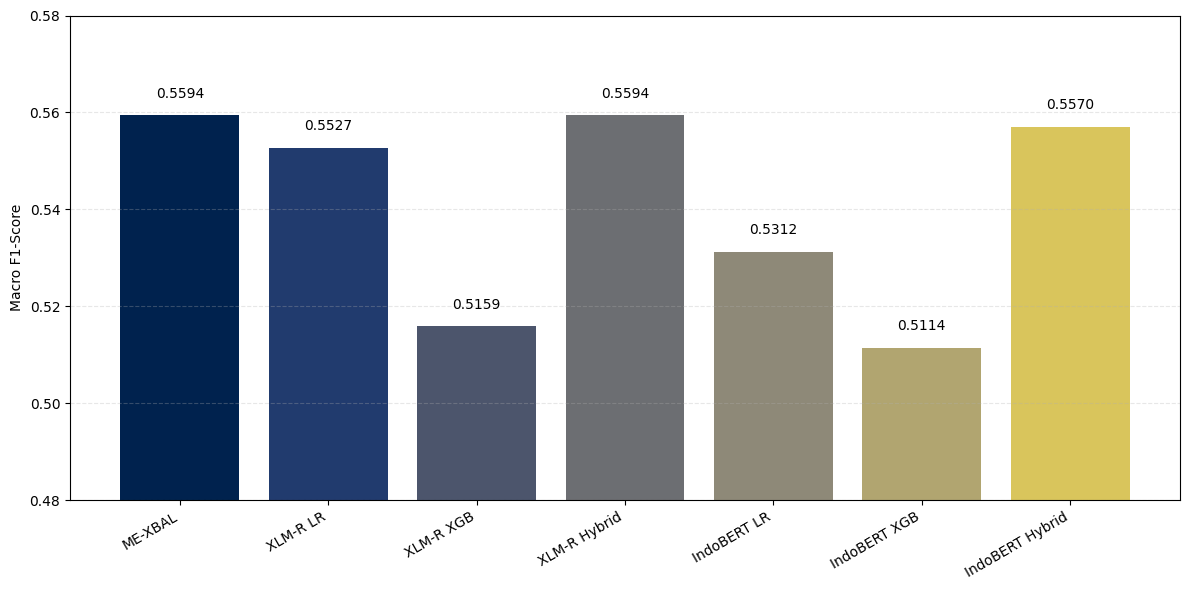

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# DATA (PAKAI HASIL YANG SUDAH ADA)
# ================================
results = {
    "ME-XBAL": 0.5594,
    "XLM-R LR": 0.5527,
    "XLM-R XGB": 0.5159,
    "XLM-R Hybrid": 0.5594,
    "IndoBERT LR": 0.5312,
    "IndoBERT XGB": 0.5114,
    "IndoBERT Hybrid": 0.5570
}

models = list(results.keys())
scores = list(results.values())

x = np.arange(len(models))

# ================================
# PLOT
# ================================
plt.figure(figsize=(12,6))

cmap = plt.cm.cividis
colors = [cmap(i/len(models)) for i in range(len(models))]

bars = plt.bar(x, scores, color=colors)

# ================================
# LABEL & TITLE
# ================================
plt.ylabel("Macro F1-Score")
# plt.title("Ablation Study on Tokopedia Dataset (Single-Label)", fontweight='bold')
plt.xticks(x, models, rotation=30, ha='right')

# ================================
# VALUE LABEL (4 DECIMAL 🔥)
# ================================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,   # lebih dekat biar rapi
        f"{height:.4f}",  # 👈 INI KUNCINYA
        ha='center',
        va='bottom',
        fontsize=10
    )

# ================================
# GRID & LIMIT
# ================================
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0.48, 0.58)  # zoom biar beda kelihatan jelas

plt.tight_layout()
plt.show()

# SHAP Explainable

In [4]:
# ==========================================
# 🔍 SHAP EXPLAINABILITY - TOKOPEDIA (SINGLE-LABEL)
# ==========================================
import shap
import numpy as np
import torch
import joblib
from transformers import AutoTokenizer, AutoModel

# ================================
# LOAD MODEL (hasil training kamu)
# ================================
# asumsi kamu punya model yang sudah dilatih di Tokopedia:
# xgb_model, lr_model, scaler, pca, le (LabelEncoder)

# ================================
# LOAD XLM-R
# ================================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# ================================
# PIPELINE FUNCTION
# ================================
def predict_proba_text(texts):
    embeddings = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb[0])

    X = np.vstack(embeddings)

    # preprocessing
    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)

    # prediction (hybrid)
    xgb_proba = xgb_model.predict_proba(X_pca)
    lr_proba  = lr_model.predict_proba(X_pca)

    proba = 0.7 * xgb_proba + 0.3 * lr_proba
    return proba

# ================================
# SHAP EXPLAINER
# ================================
explainer = shap.Explainer(
    predict_proba_text,
    shap.maskers.Text(tokenizer)
)

# ================================
# SAMPLE TEXT (AMBIL DARI DATASET)
# ================================
sample_texts = [
    "Barangnya bagus banget, pengiriman cepat dan sesuai deskripsi",
    "Kecewa, kualitas produk jelek dan tidak sesuai ekspektasi"
]

# ================================
# COMPUTE SHAP
# ================================
shap_values = explainer(sample_texts)

# ================================
# VISUALIZATION
# ================================
for i, text in enumerate(sample_texts):
    print("="*80)
    print(f"📝 Text: {text}")
    print("="*80)
    
    shap.plots.text(shap_values[i])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📝 Text: Barangnya bagus banget, pengiriman cepat dan sesuai deskripsi


📝 Text: Kecewa, kualitas produk jelek dan tidak sesuai ekspektasi


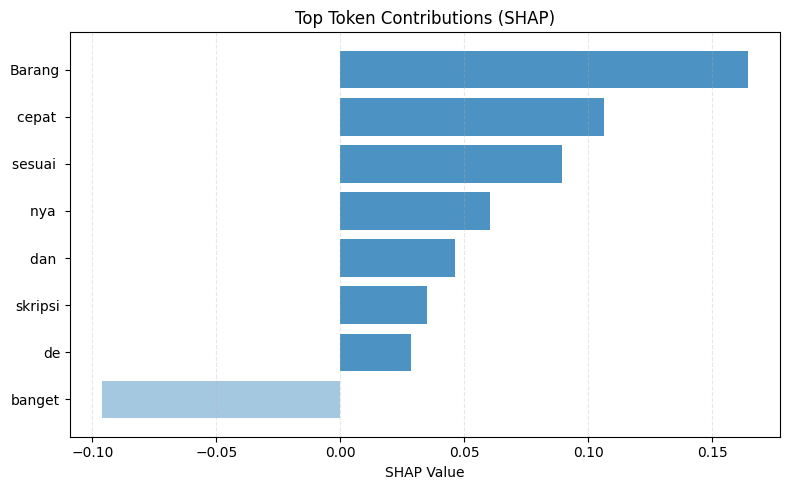

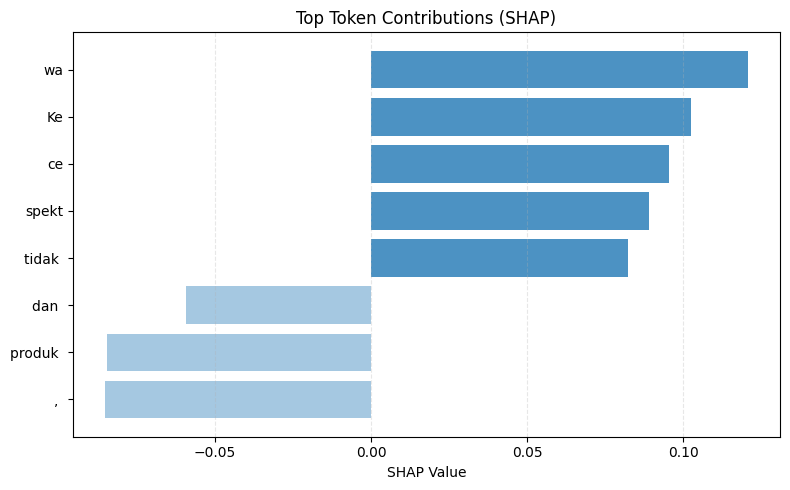

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# FUNCTION: SHAP BAR PLOT
# ================================
def plot_shap_bar(shap_values, text_index=0, top_k=10, class_index=None):
    
    # Ambil SHAP untuk satu teks
    sv = shap_values[text_index]
    
    # Kalau multi-class → pilih class dengan prob tertinggi
    if class_index is None:
        class_index = np.argmax(sv.values.sum(axis=0))
    
    values = sv.values[:, class_index]
    tokens = sv.data
    
    # Ambil top-k berdasarkan magnitude
    idx = np.argsort(np.abs(values))[-top_k:]
    
    selected_values = values[idx]
    selected_tokens = tokens[idx]
    
    # Sorting biar rapi
    sorted_idx = np.argsort(selected_values)
    selected_values = selected_values[sorted_idx]
    selected_tokens = selected_tokens[sorted_idx]
    
    # ================================
    # PLOT
    # ================================
    plt.figure(figsize=(8,5))
    
    bars = plt.barh(range(len(selected_tokens)), selected_values)
    
    # warna otomatis: negatif vs positif
    for i, bar in enumerate(bars):
        if selected_values[i] > 0:
            bar.set_alpha(0.8)
        else:
            bar.set_alpha(0.4)
    
    plt.yticks(range(len(selected_tokens)), selected_tokens)
    plt.xlabel("SHAP Value")
    plt.title("Top Token Contributions (SHAP)")
    
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ================================
# APPLY KE SAMPLE
# ================================
plot_shap_bar(shap_values, text_index=0, top_k=8)
plot_shap_bar(shap_values, text_index=1, top_k=8)